<a href="https://colab.research.google.com/github/0v3r-9000/trc204.github.io/blob/main/CA_Wildfire_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set-Up

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Set some display options for pandas DataFrames
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Set the style for matplotlib plots
plt.style.use('seaborn-v0_8-darkgrid')

# Set the default figure size for plots
plt.rcParams['figure.figsize'] = (10, 6)

# Set the default font size for plots
plt.rcParams['font.size'] = 12

# Set the default color palette for seaborn plots
sns.set_palette('viridis')

In [3]:
df = pd.read_csv("/content/data.csv")
df.head()

,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),Cause
0,INC1000,2020-11-22,Sonoma County,14048,763,474,235,70,19,2270.57,Lightning
1,INC1001,2021-09-23,Sonoma County,33667,1633,4,263,100,2,1381.14,Lightning
2,INC1002,2022-02-10,Shasta County,26394,915,291,31,50,6,2421.96,Human Activity
3,INC1003,2021-05-17,Sonoma County,20004,1220,128,34,28,0,3964.16,Unknown
4,INC1004,2021-09-22,Sonoma County,40320,794,469,147,0,15,1800.09,Unknown


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.strftime('%Y')
df = df.sort_values(by='Date', ascending=True)
df

,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),Cause
28,INC1028,2014,Butte County,17860,1819,391,45,20,15,1975.26,Unknown
98,INC1098,2014,Napa Valley,1338,1619,262,293,94,3,3308.74,Human Activity
47,INC1047,2014,San Diego County,28661,276,313,89,7,10,3485.12,Unknown
74,INC1074,2014,Napa Valley,9737,1735,386,52,44,10,4075.67,Lightning
45,INC1045,2014,Sonoma County,21703,735,279,294,3,1,1305.34,Human Activity
42,INC1042,2014,San Diego County,6651,1559,43,102,13,5,2024.82,Human Activity
38,INC1038,2014,Mendocino County,41647,484,210,180,7,16,286.64,Lightning
37,INC1037,2014,Shasta County,21502,1763,452,218,7,3,1653.22,Lightning
65,INC1065,2014,Mendocino County,36554,914,293,240,98,5,567.31,Unknown
61,INC1061,2014,Los Angeles County,11162,544,223,196,100,8,85.57,Unknown


# Number of Wildfires per Year

Date
2014    13
2015     9
2016     9
2017     5
2018    12
2019     8
2020     8
2021    13
2022    12
2023    11
Name: count, dtype: int64


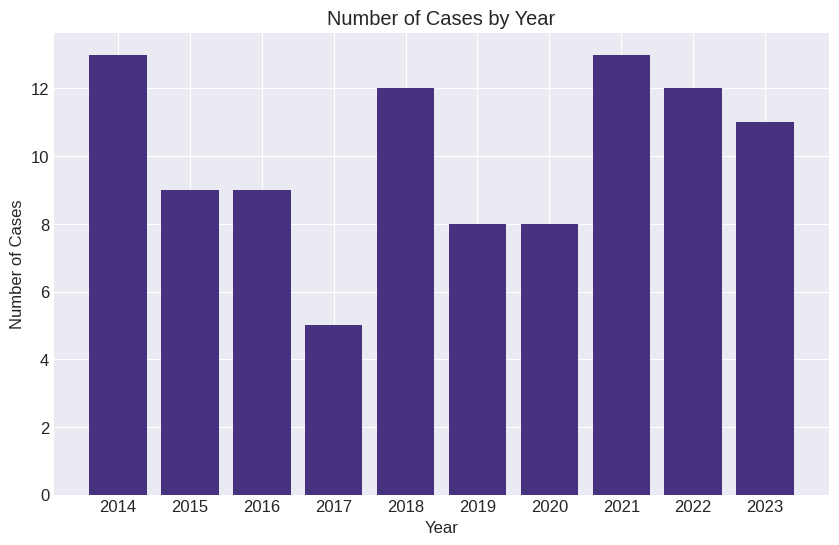

In [12]:
most_year = df['Date'].value_counts().sort_index()
most_year_X = most_year.index
most_year_Y = most_year.values

print(most_year)

plt.bar(most_year_X, most_year_Y)
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.title('Number of Cases by Year')
plt.show()

# Top Counties for Fires

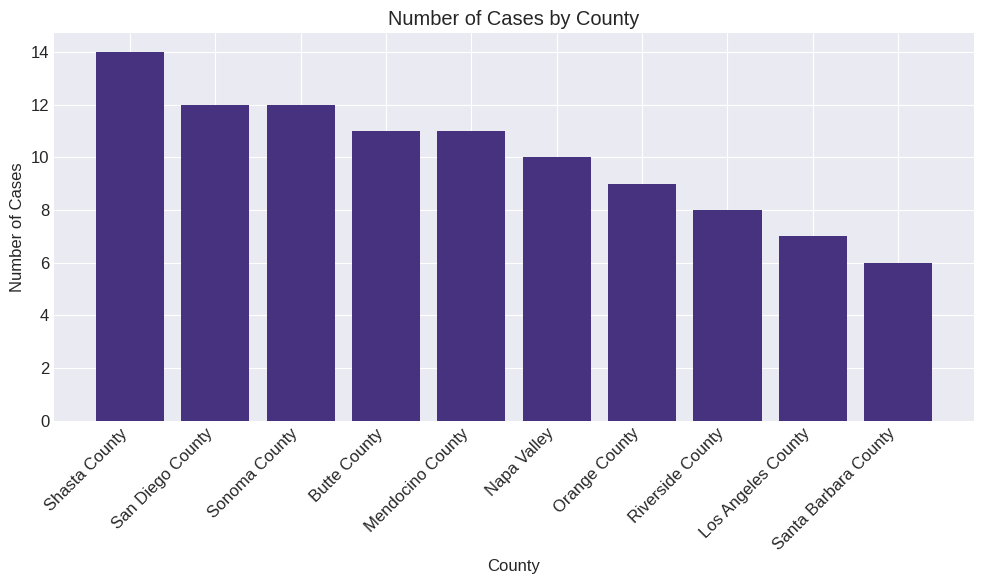

In [6]:
most_counties = df['Location'].value_counts()
most_counties_X = most_counties.index
most_counties_Y = most_counties.values
plt.bar(most_counties_X, most_counties_Y)
plt.xlabel('County')
plt.ylabel('Number of Cases')
plt.title('Number of Cases by County')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Top Cause of Fires

Text(0.5, 1.0, 'Number of Cases by Cause')

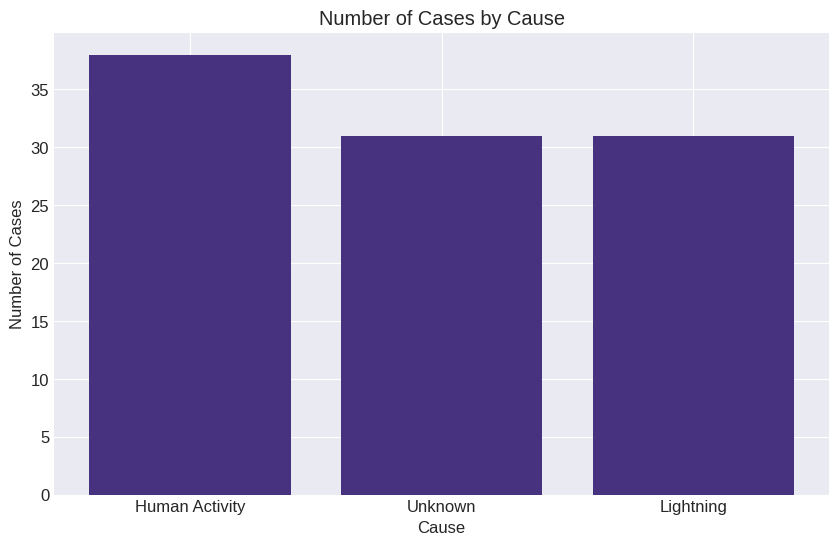

In [7]:
top_cause = df['Cause'].value_counts()
top_cause_X = top_cause.index
top_cause_Y = top_cause.values

plt.bar(top_cause_X, top_cause_Y)
plt.xlabel('Cause')
plt.ylabel('Number of Cases')
plt.title('Number of Cases by Cause')

# Acres Burned by Year

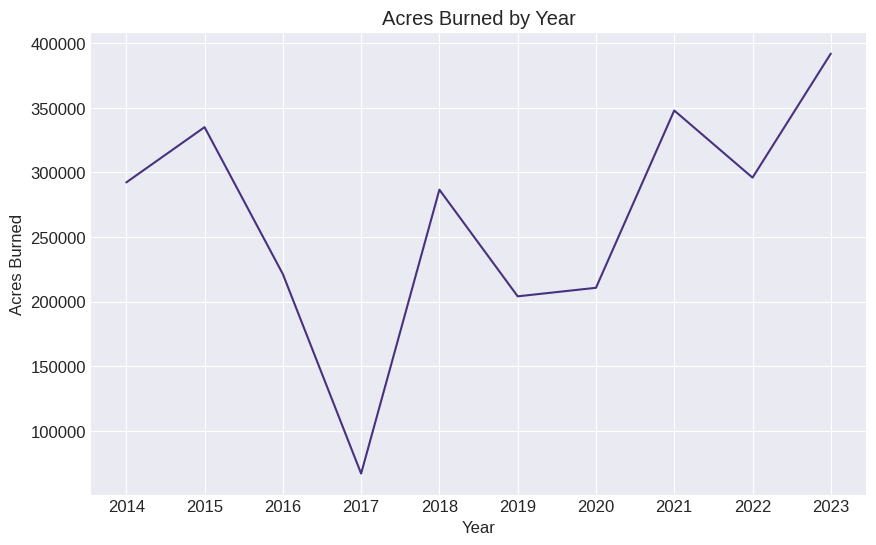

In [8]:
acres_burned = df.groupby('Date')['Area_Burned (Acres)'].sum()

acres_burned_X = acres_burned.index
acres_burned_Y = acres_burned.values

plt.plot(acres_burned_X, acres_burned_Y)
plt.xlabel('Year')
plt.ylabel('Acres Burned')
plt.title('Acres Burned by Year')
plt.show()

# Financial Damages

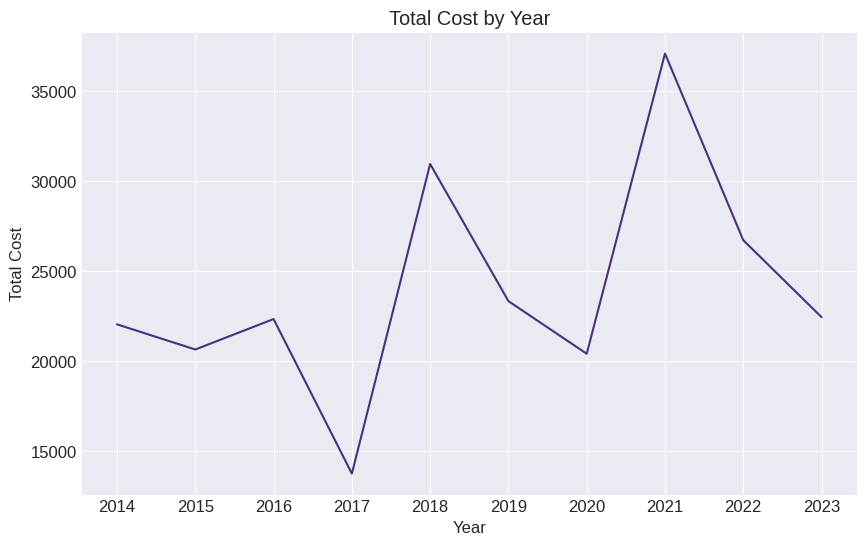

In [9]:
total_cost = df.groupby('Date')['Estimated_Financial_Loss (Million $)'].sum()

total_cost_X = total_cost.index
total_cost_Y = total_cost.values

plt.plot(total_cost_X, total_cost_Y)
plt.xlabel('Year')
plt.ylabel('Total Cost')
plt.title('Total Cost by Year')
plt.show()

# Cost Occurred by County

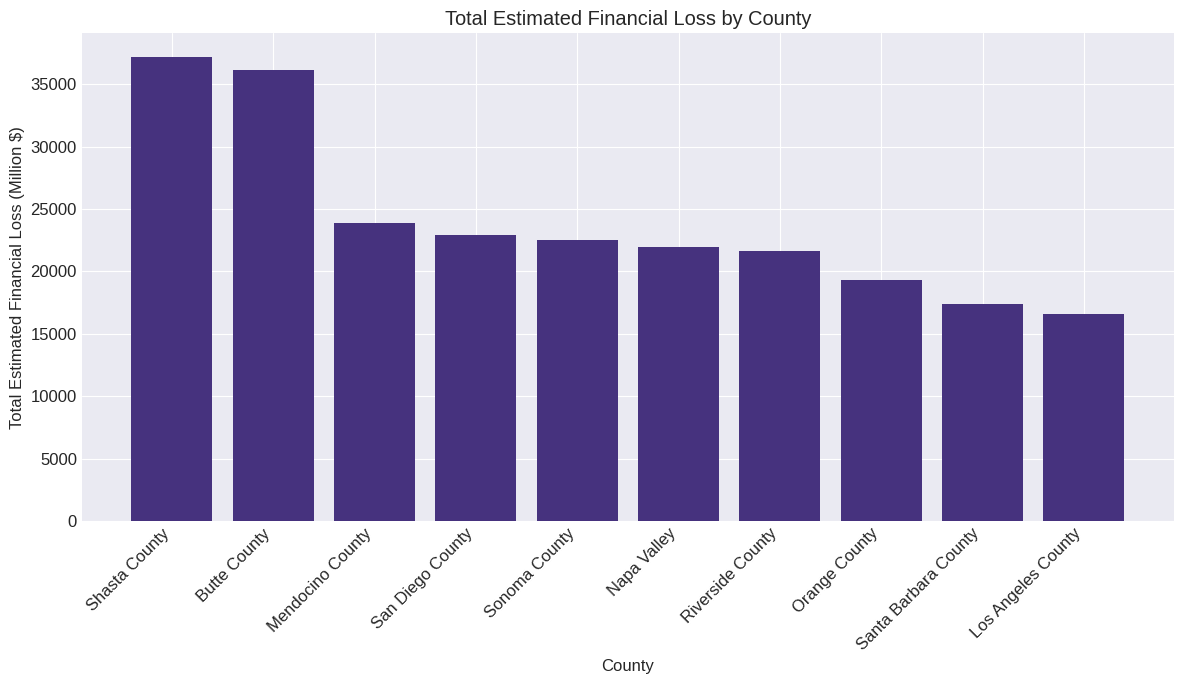

In [10]:
cost_by_county = df.groupby('Location')['Estimated_Financial_Loss (Million $)'].sum().sort_values(ascending=False)
cost_by_county_X = cost_by_county.index
cost_by_county_Y = cost_by_county.values

plt.figure(figsize=(12, 7))
plt.bar(cost_by_county_X, cost_by_county_Y)
plt.xlabel('County')
plt.ylabel('Total Estimated Financial Loss (Million $)')
plt.title('Total Estimated Financial Loss by County')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [11]:
avg_cost_per_wildfire_by_county = df.groupby('Location')['Estimated_Financial_Loss (Million $)'].mean().sort_values(ascending=False)
display(avg_cost_per_wildfire_by_county)

,Estimated_Financial_Loss (Million $)
Location,
Butte County,3289.802727
Santa Barbara County,2899.543333
Riverside County,2707.867500
Shasta County,2659.445714
Los Angeles County,2371.347143
Napa Valley,2194.682000
Mendocino County,2169.524545
Orange County,2144.695556
San Diego County,1909.546667


# Data Story

In [40]:
print("---------- Wildfire Analysis ------------")
print("")
print(f"Total number of fires from 2014 to 2023: {len(df)}")
print("")
print("----------------------------------------")
print("")
print(f"The year with most acres burned was {acres_burned_X[0]}. {acres_burned_Y[0]} acres were burned ultimately totaling {total_cost_Y[0]} million dollars in damage.")
print("")
print("----------------------------------------")
print("")
print(f"The county with most fires was {most_counties_X[0]} with the number one reason for fires being {top_cause_X[0]}.")



---------- Wildfire Analysis ------------

Total number of fires from 2014 to 2023: 100

----------------------------------------

The year with most acres burned was 2014. 292258 acres were burned ultimately totaling 22034.1 million dollars in damage.

----------------------------------------

The county with most fires was Shasta County with the number one reason for fires being Human Activity.
